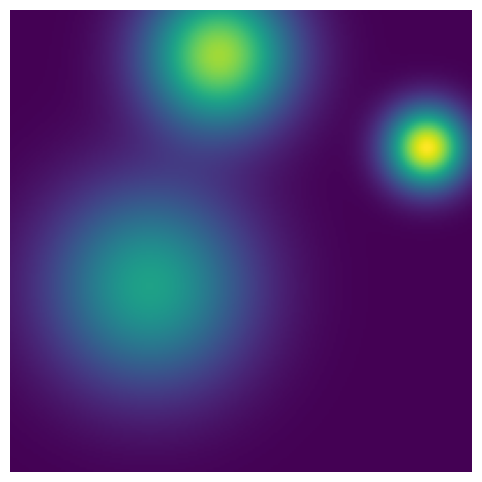

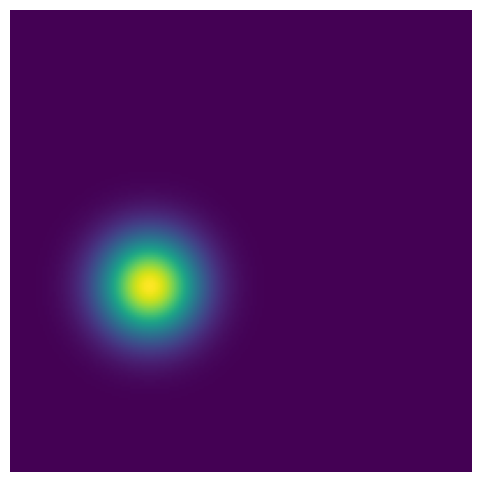

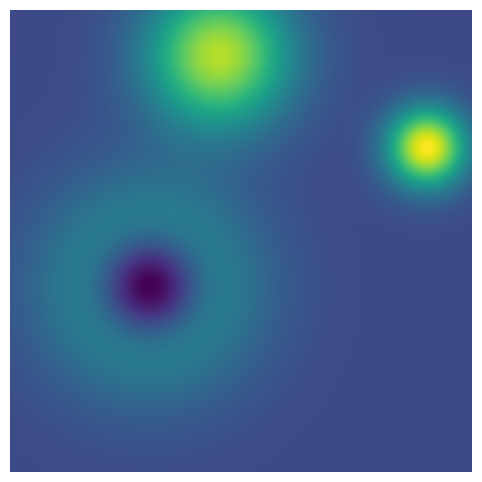

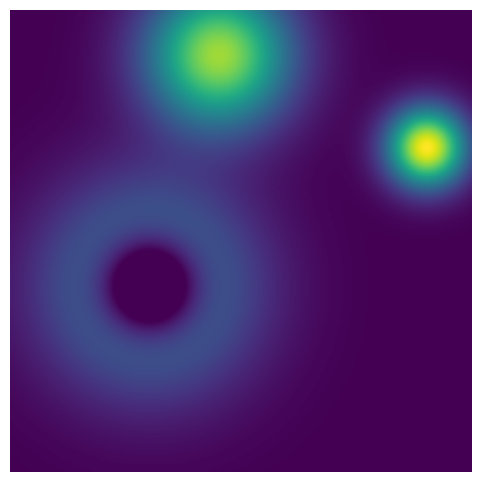

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import matplotlib.patheffects as path_effects

def make_2d_gaussian(shape, centers, sigmas, strengths):
    """
    Generates a 2D array with summed Gaussians.
    
    Parameters:
        shape (tuple): The height and width of the image (h, w).
        centers (list): List of (x, y) tuples for the centers.
        sigmas (list): List of sigma values (width) for each Gaussian.
        strengths (list): List of amplitude values for each Gaussian.
        
    Returns:
        np.ndarray: The 2D image array.
    """
    h, w = shape
    image = np.zeros((h, w), dtype=np.float32)

    # Create a coordinate grid
    # defined from 0 to w and 0 to h
    x = np.arange(0, w)
    y = np.arange(0, h)
    X, Y = np.meshgrid(x, y)

    # Loop through the requested Gaussians and add them to the image
    for center, sigma, strength in zip(centers, sigmas, strengths):
        x0, y0 = center
        
        # Calculate the squared distance from the center for every pixel
        dist_sq = (X - x0)**2 + (Y - y0)**2
        
        # Gaussian formula
        gaussian = strength * np.exp(-dist_sq / (2 * sigma**2))
        
        # Add to the canvas
        image += gaussian

    return image

def make_3d_gaussian(shape, centers, sigmas, strengths):
    """
    Generates a 3D array with summed Gaussians.
    Parameters:
        shape (tuple): The dimensions (w, d, h) of the volume.
        centers (list): List of (x, y, z) tuples for the centers.
        sigmas (list): List of sigma values (width) for each Gaussian.
        strengths (list): List of amplitude values for each Gaussian.
    Returns:
        np.ndarray: The 3D volume array.
    """
    w, d, h = shape
    volume = np.zeros((w, d, h), dtype=np.float32)
    
    # Create a coordinate grid
    x = np.arange(0, w)
    y = np.arange(0, d)
    z = np.arange(0, h)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    # Loop through the requested Gaussians and add them to the volume
    for center, sigma, strength in zip(centers, sigmas, strengths):
        x0, y0, z0 = center
        # Calculate the squared distance from the center for every voxel
        dist_sq = (X - x0)**2 + (Y - y0)**2 + (Z - z0)**2
        # Gaussian formula
        gaussian = strength * np.exp(-dist_sq / (2 * sigma**2))
        # Add to the canvas
        volume += gaussian
    
    return volume

# --- Configuration ---
img_shape = (200, 200)  # Height, Width

# Define your Gaussians here
# Format: (x_coordinate, y_coordinate)
# locations = [(50, 50), (160, 160), (150, 50), (57, 125)]
# widths    = [15,       25,         35,               20]        # Sigma (spread)
# amplitudes= [1.8,      1.7,        1.7,             1.6]       # Strength (peak value)

locations_neg = [(60, 80)]
widths_neg    = [15]        # Sigma (spread)
amplitude_neg= [1.8]       # Strength (peak value)

locations = [(60, 80), (180, 140), (90, 180)]
widths    = [30,       12,         22]
amplitudes= [1.2,      2.1,        1.8]

# --- Generate and Plot ---
result_image = make_2d_gaussian(img_shape, locations, widths, amplitudes)

plt.figure(figsize=(8, 6))
plt.axis('off')
# origin='lower' puts (0,0) at bottom-left. remove it to put (0,0) at top-left like an image.
plt.imshow(result_image, cmap='viridis', origin='lower') 
plt.show()

# --- Generate and Plot ---
result_image_2 = make_2d_gaussian(img_shape, locations_neg, widths_neg, amplitude_neg)

plt.figure(figsize=(8, 6))
plt.axis('off')
# origin='lower' puts (0,0) at bottom-left. remove it to put (0,0) at top-left like an image.
plt.imshow(result_image_2, cmap='viridis', origin='lower') 
plt.show()

# Fused

fused_image = result_image - result_image_2

plt.figure(figsize=(8, 6))
plt.axis('off')
# origin='lower' puts (0,0) at bottom-left. remove it to put (0,0) at top-left like an image.
plt.imshow(fused_image, cmap='viridis', origin='lower') 
plt.show()

# ReLU
fused_image[fused_image < 0] = 0

plt.figure(figsize=(8, 6))
plt.axis('off')
# origin='lower' puts (0,0) at bottom-left. remove it to put (0,0) at top-left like an image.
plt.imshow(fused_image, cmap='viridis', origin='lower') 
plt.show()

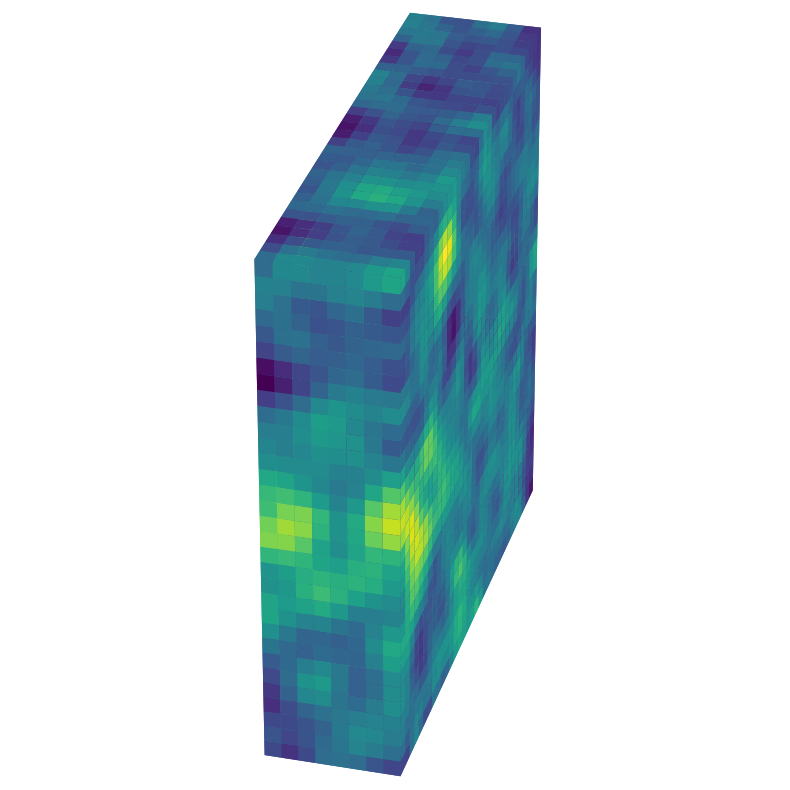

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LightSource
from scipy.ndimage import gaussian_filter

# 1. Setup Dimensions and Random "Texture" Data
w, h, d = 32, 32, 8
shape = (w, d, h)
type = "blobs"

if type == "random":
    # Create Perlin-like noise texture
    scale = 10.0
    texture_data = np.random.rand(w, d, h)
    texture_data = gaussian_filter(texture_data, sigma=1)

elif type == "blobs":

    scale = 10.0
    texture_data = np.random.rand(w, d, h)
    texture_data = gaussian_filter(texture_data, sigma=1)

    # multiply with fused_image resized to 32x32
    resized_image = zoom(fused_image, (w / img_shape[0], h / img_shape[1]), order=1)
    # repeat for channels
    resized_image = resized_image[:, np.newaxis]
    blend_factor = 0.15
    texture_data = blend_factor * resized_image + (1 - blend_factor) * texture_data



elif type == "from_2d":
    
    resized_image = zoom(fused_image, (w / img_shape[0], h / img_shape[1]), order=1)
    texture_data = resized_image.reshape((w, d, h))
# Normalize to 0-1
texture_data = (texture_data - texture_data.min()) / (texture_data.max() - texture_data.min())

# downsize the result_image to 32x32 and use it as texture data
# from scipy.ndimage import zoom
# resized_image = zoom(result_image, (w / img_shape[0], h / img_shape[1]), order=1)
# texture_data = resized_image.reshape((w, d, h))
# # Normalize to 0-1
# texture_data = (texture_data - texture_data.min()) / (texture_data.max() - texture_data.min())

# gamma = 0.5  # Values less than 1 brighten, greater than 1 darken
# texture_data = texture_data ** gamma


# 2. Convert Data to Colors
# We use a colormap (e.g., 'viridis', 'plasma', 'inferno') to map values to colors
colormap = plt.cm.viridis
colors = colormap(texture_data)

# 3. Plotting
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# ax.voxels expects:
# - filled: A boolean array where True = draw a voxel. We want a solid cuboid, so all True.
# - facecolors: The color array we created above.
# - edgecolors: Set to None or 'k'. None creates a smoother "texture" look.
ax.voxels(np.ones(shape, dtype=bool), facecolors=colors, edgecolors=None, shade=False)

# 4. Formatting (Visual cleanup)
# Set limits
ax.set_xlim(0, w)
ax.set_ylim(0, d)
ax.set_zlim(0, h)

# Correct aspect ratio
ax.set_box_aspect((w, d, h))

# Rotate view (optional)
ax.view_init(elev=30, azim=15)

# Remove texts and axis
ax.set_axis_off()
plt.savefig('../plots/reweight_features.png', transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()

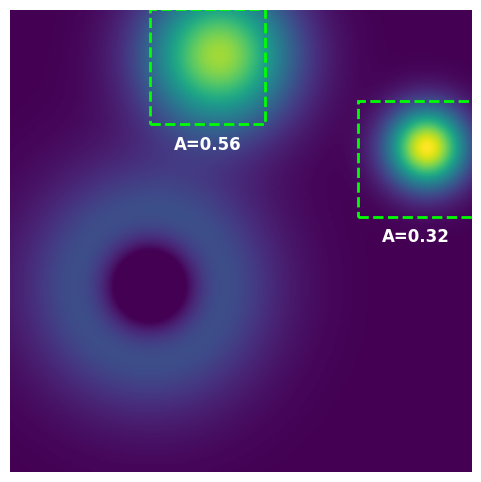

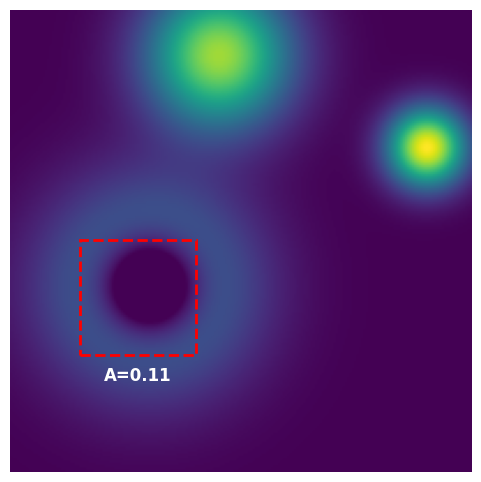

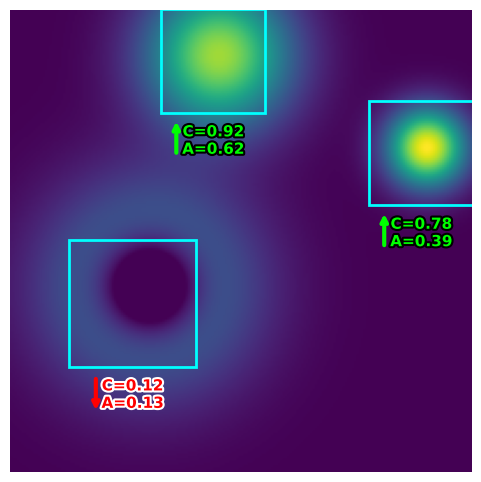

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_assl_positive(attention_map, pos_boxes, output_path='assl_pos.png'):
    """
    Visualizes the positive loss component.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(attention_map, cmap='viridis', origin='lower')
    for (x, y, w, h) in pos_boxes:
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        region = attention_map[int(y):int(y+h), int(x):int(x+w)]
        mu_pos = region.mean()
        ax.text(x + w/2, y - 5, f'A={mu_pos:.2f}', ha='center', va='top', 
                color='white', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.savefig(output_path, dpi=150, bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()


def visualize_assl_negative(attention_map, neg_boxes, output_path='assl_neg.png'):
    """
    Visualizes the negative loss component.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(attention_map, cmap='viridis', origin='lower')
    for (x, y, w, h) in neg_boxes:
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        region = attention_map[int(y):int(y+h), int(x):int(x+w)]
        mu_neg = region.mean()
        ax.text(x + w/2, y - 5, f'A={mu_neg:.2f}', ha='center', va='top',
                color='white', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.savefig(output_path, dpi=150, bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()


def visualize_assl_prediction(attention_map, pred_boxes, pred_confidences, arrow_directions, output_path='assl_pred.png'):
    """
    Visualizes the prediction consistency component with manually specified arrows.
    
    Parameters:
        attention_map: 2D numpy array of attention scores
        pred_boxes: List of (x, y, w, h) tuples for predicted boxes
        pred_confidences: List of confidence scores
        arrow_directions: List of 'up', 'down', or None for each box
        output_path: Output file path
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(attention_map, cmap='viridis', origin='lower')
    
    for i, (x, y, w, h) in enumerate(pred_boxes):
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='cyan', facecolor='none')
        ax.add_patch(rect)
        region = attention_map[int(y):int(y+h), int(x):int(x+w)]
        mu_attn = region.mean()
        conf = pred_confidences[i]

        # Determine color and path effect based on arrow direction
        direction = arrow_directions[i]
        if direction == 'up':
            text_color = 'lime'
            stroke_color = 'black'
        elif direction == 'down':
            text_color = 'red'
            stroke_color = 'white'
        else:
            text_color = 'white'
            stroke_color = 'black'
        
        # Define path effect
        text_path_effect = [path_effects.Stroke(linewidth=3, foreground=stroke_color),
                           path_effects.Normal()]
        
        # Text annotation with matching color and path effect
        ax.text(x + w/2, y - 5, f'C={conf:.2f}\nA={mu_attn:.2f}', ha='center', va='top',
                color=text_color, fontsize=11, fontweight='bold',
                path_effects=text_path_effect)
        
        # Draw arrow based on specified direction
        # arrow_x = x + w/2 - w/3
        # arrow_y = y - 8
        # arrow_length = 8
        # direction = arrow_directions[i]

        direction = arrow_directions[i]
        
        if direction == 'up':
            arrow_x = x + w/2 - w/3 - 1
            arrow_y = y - 10.5
            arrow_length = 8

            ax.annotate('', 
                        xy=(arrow_x, arrow_y + arrow_length),
                        xytext=(arrow_x, arrow_y - arrow_length),
                        arrowprops=dict(arrowstyle='->', color='lime', lw=3))
        elif direction == 'down':

            arrow_x = x + w/2 - w/3 + 2.5
            arrow_y = y - 12
            arrow_length = 8

            ax.annotate('', 
                        xy=(arrow_x, arrow_y - arrow_length),
                        xytext=(arrow_x, arrow_y + arrow_length),
                        arrowprops=dict(arrowstyle='->', color='red', lw=3))
    
    ax.axis('off')
    plt.savefig(output_path, dpi=150, bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()


# Example usage
img_shape = (200, 200)

locations = [(60, 80), (180, 140), (90, 180)]
widths = [30, 12, 22]
amplitudes = [1.2, 2.1, 1.8]

locations_neg = [(60, 80)]
widths_neg = [15]
amplitude_neg = [1.8]

result_image = make_2d_gaussian(img_shape, locations, widths, amplitudes)
result_image_neg = make_2d_gaussian(img_shape, locations_neg, widths_neg, amplitude_neg)
fused_image = result_image - result_image_neg
fused_image[fused_image < 0] = 0

# Normalize for visualization
attention_map = (fused_image - fused_image.min()) / (fused_image.max() - fused_image.min())

# Define example boxes (x, y, width, height)
pos_boxes = [(150, 110, 50, 50), (60, 150, 50, 50)]
neg_boxes = [(30, 50, 50, 50)]
pred_boxes = [(155, 115, 45, 45), (65, 155, 45, 45), (25, 45, 55, 55)]
pred_confidences = [0.78, 0.92, 0.12]
arrow_directions = ['up', 'up', 'down']  # Two positive, one negative

# Generate individual plots
visualize_assl_positive(attention_map, pos_boxes, '../plots/assl_pos.png')
visualize_assl_negative(attention_map, neg_boxes, '../plots/assl_neg.png')
visualize_assl_prediction(attention_map, pred_boxes, pred_confidences, arrow_directions, '../plots/assl_pred.png')